# 08 · Wind power curves: every window its own design

Kelmarsh wind farm, six turbines, 10-minute SCADA (CC-BY-4.0; the first run
downloads ~270 MB into `.cache/wind/` and checks its sha256). One window is a
turbine over six hours: $x$ the wind speed it happened to see, $y$ the power
as a share of rated. No two windows share a design, so there is no raw
profile -- a profile method has to bin each window's curve first.

The archive has **no operator labels** (checked: curtailment columns empty,
setpoint never caps output), so the blocks are scored against physical
proxies: colder air, wake from a neighbour, and night vs day as a negative
control.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

In [2]:
from experiments.wind.windows import build
b = build()
m = b.meta
print(f"{len(b.X)} blocks; median wind-speed bins covered: {m.coverage.median():.0f} of 24")
for p in ("cold", "waked", "night"):
    print(f"{p:6s}", m[p].value_counts().to_dict())

14626 blocks; median wind-speed bins covered: 7 of 24
cold   {1: 7116, 0: 7116, -1: 394}
waked  {0: 7398, -1: 5375, 1: 1853}
night  {-1: 7318, 1: 3667, 0: 3641}


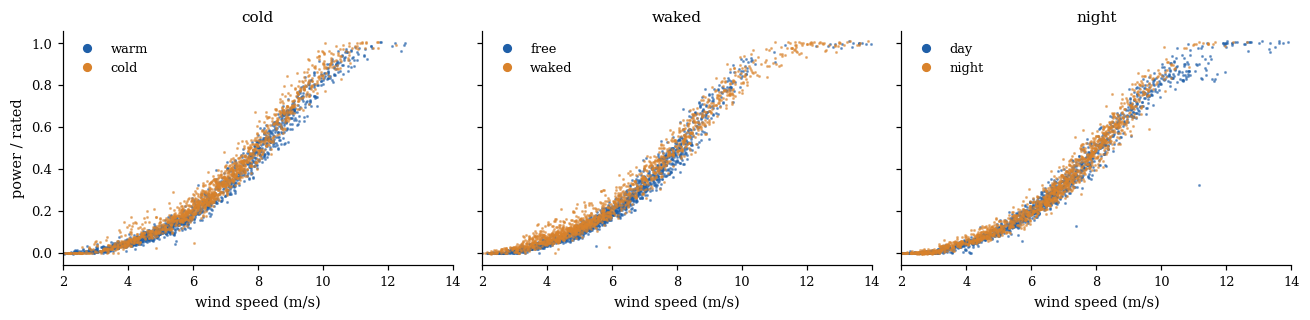

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
rng = np.random.default_rng(0)
for ax, (proxy, names) in zip(axes, (("cold", ("warm", "cold")), ("waked", ("free", "waked")),
                                     ("night", ("day", "night")))):
    for k in (0, 1):
        idx = rng.choice(np.flatnonzero(m[proxy].to_numpy() == k), 40, replace=False)
        for i in idx:
            ax.plot(b.X[i][:, 0], b.y[i], ".", ms=2, color=viz.regime_color(k), alpha=0.5)
        ax.plot([], [], "o", color=viz.regime_color(k), label=names[k])
    ax.set(title=proxy, xlabel="wind speed (m/s)", xlim=(2, 14)); ax.legend()
axes[0].set_ylabel("power / rated"); fig.tight_layout()

## Transfer across turbines

Trained on turbines 1-3, tested on 4-6 and back; balanced error. The law
classifier against the method of bins, and V1's ceiling for a clean
two-law proxy:

method,bins_1nn,bins_centroid,bins_logistic,law,law_L1,mech_logistic
proxy,,,,,,
cold,0.351,0.436,0.415,0.305,0.317,0.359
night,0.426,0.459,0.431,0.423,0.432,0.449
waked,0.421,0.486,0.406,0.353,0.381,0.374


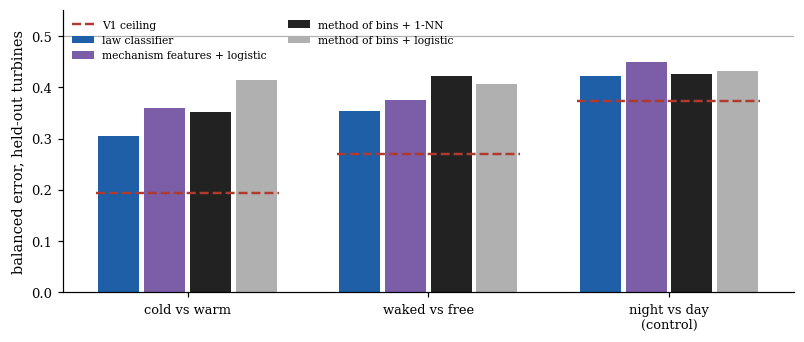

In [4]:
from analysis.figs_wind import wind_transfer, wind_physics
wind_transfer()
t = pd.read_csv(RES / "wind" / "wind_transfer.csv")
t.pivot_table(index="proxy", columns="method", values="balanced_error").round(3)

In [5]:
pd.read_csv(RES / "wind" / "wind_coverage_terciles.csv").pivot_table(
    index=["proxy", "coverage"], columns="method", values="balanced_error").round(3)

method          bins_1nn  bins_logistic    law
proxy coverage                                
cold  middle       0.347          0.417  0.289
      narrow       0.385          0.405  0.322
      wide         0.310          0.441  0.299
night middle       0.463          0.465  0.423
      narrow       0.418          0.478  0.413
      wide         0.419          0.421  0.414
waked middle       0.420          0.388  0.350
      narrow       0.427          0.420  0.364
      wide         0.423          0.429  0.357

## The physics check

Below rated, power scales with air density. The cold/warm ratio of the
recovered curves against the density ratio the temperatures imply:

,ws,bins_ratio,law_ratio,law_uniform_ratio,density_ratio
0,4.25,1.202,1.197,1.215,1.032
1,4.75,1.161,1.157,1.157,1.032
2,5.25,1.132,1.132,1.124,1.032
3,5.75,1.106,1.103,1.107,1.032
4,6.25,1.098,1.101,1.097,1.032
5,6.75,1.090,1.082,1.089,1.032
6,7.25,1.085,1.088,1.081,1.032
7,7.75,1.076,1.070,1.075,1.032
8,8.25,1.075,1.076,1.073,1.032
9,8.75,1.072,1.086,1.073,1.032


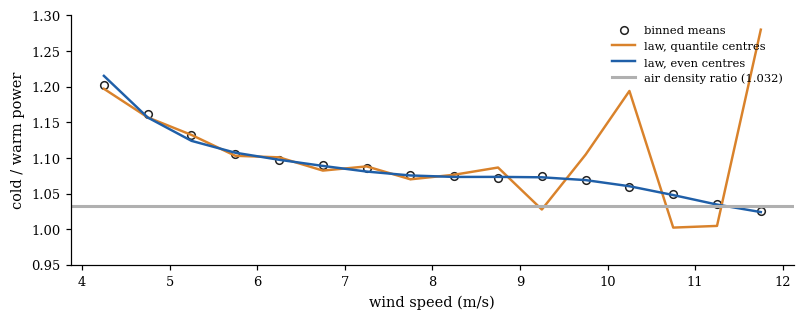

In [6]:
wind_physics()
pd.read_csv(RES / "wind" / "wind_physics.csv")[["ws", "bins_ratio", "law_ratio",
                                                "law_uniform_ratio", "density_ratio"]].round(3)

## In real time

Each turbine streamed on its own. The regimes born, and when:

In [7]:
on = pd.read_csv(RES / "wind" / "wind_online.csv")
on[on.regime >= 0].merge(m.assign(born_at=m.block.astype(str))[
    ["turbine", "born_at", "ws_mean", "temp"]], on=["turbine", "born_at"], how="left").round(1)

,turbine,born_at,month,regime,ws_mean_x,ws_percentile,temp_x,streamed,final_regimes,buffered_share,ws_mean_y,temp_y
0,1,2016-07-20 06:00:00,7,2,6.9,0.7,25.1,NaN,NaN,NaN,6.9,25.1
1,1,2016-11-25 12:00:00,11,3,8.9,0.9,8.8,NaN,NaN,NaN,8.9,8.8
2,1,2016-12-25 12:00:00,12,4,11.6,1.0,13.0,NaN,NaN,NaN,11.6,13.0
3,1,2017-05-24 00:00:00,5,5,6.5,0.6,16.2,NaN,NaN,NaN,6.5,16.2
4,2,2016-11-25 00:00:00,11,2,8.3,0.8,5.9,NaN,NaN,NaN,8.3,5.9
5,2,2016-12-24 12:00:00,12,3,11.7,1.0,9.4,NaN,NaN,NaN,11.7,9.4
6,2,2017-07-04 18:00:00,7,4,5.3,0.4,19.0,NaN,NaN,NaN,5.3,19.0
7,2,2017-11-29 06:00:00,11,5,9.2,0.9,3.1,NaN,NaN,NaN,9.2,3.1
8,3,2016-07-21 18:00:00,7,2,5.4,0.4,18.5,NaN,NaN,NaN,5.4,18.5
9,4,2016-11-28 12:00:00,11,2,5.7,0.5,7.4,NaN,NaN,NaN,5.7,7.4
